Laboratorio 5: Incisos del 8 al 9

In [28]:
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB

In [7]:
filename= 'datos_limpios.csv'
data= pd.read_csv(filename)
df=pd.DataFrame(data)
df.head()

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,room_type_Hotel room,room_type_Private room,room_type_Shared room,calendar_last_scraped_2025-09-16,calendar_last_scraped_2025-09-17,calendar_last_scraped_2025-09-22,calendar_last_scraped_2025-09-23,calendar_last_scraped_2025-09-24,calendar_last_scraped_2025-09-25,calendar_last_scraped_2025-09-30
0,1.0,2.0,30.26057,-97.73441,3,1.0,1.0,2.0,97.0,2,...,0,0,0,0,1,0,0,0,0,0
1,1.0,2.0,30.26034,-97.76487,2,1.0,1.0,2.0,160.0,3,...,0,0,0,0,1,0,0,0,0,0
2,1.0,1.0,30.23466,-97.73682,2,1.0,1.0,1.0,38.0,4,...,0,0,0,0,1,0,0,0,0,0
3,2.0,2.0,30.26098,-97.73072,3,2.0,2.0,2.0,145.0,15,...,0,0,0,0,1,0,0,0,0,0
4,1.0,1.0,30.23614,-97.73225,2,1.0,1.0,1.0,58.0,30,...,0,0,0,1,0,0,0,0,0,0


Tratamiento de datos NaN

In [8]:
df = df.fillna(df.median(numeric_only=True))

Separacion de datos en entrenamiento y prueba

In [9]:
categoria = []
#clasificacion de variable objetivo
for x in df['price']:
    if x <= 120:
        categoria.append('Económica')
    elif x < 330:
        categoria.append('Intermedia')
    else:
        categoria.append('Cara')
df = df.drop(columns=['price'])

#Separacion de datos
X_train, X_test, y_train, y_test = train_test_split(df, categoria, test_size=0.2, random_state=0, stratify=categoria)

Escalamiento

In [10]:
columnas=X_train.columns
scaler = MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [11]:
X_train=pd.DataFrame(X_train, columns=columnas)
X_test=pd.DataFrame(X_test, columns=columnas)


Eliminación de datos atípicos

In [12]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 3 * IQR
sup = Q3 + 3 * IQR

Problema 8: Validación cruzada

In [21]:
#La siguiente hace validación cruzada de un modelo ne Naive Bayes
def NBCV(X, y, cv=5, scoring="accuracy"):
    
    modeloNB = GaussianNB(var_smoothing=1e-20)
    
    kfold = StratifiedKFold(n_splits=cv,shuffle=True,random_state=0)
    
    scores = cross_val_score(modeloNB,X,y,cv=kfold,scoring=scoring)
    
    return {
        "scores": scores,
        "mean": np.mean(scores),
        "std": np.std(scores)
    }

In [22]:
pd.DataFrame(NBCV(X_train, y_train, cv=2))

,scores,mean,std
0,0.389259,0.429019,0.03976
1,0.468779,0.429019,0.03976


Se observa que el valor de la Exactitud (accuracy) es mayor en ambas iteraciones que el valor del modelo del inciso anterior, ya que este valor en el inciso anterior era de $0.38885112168592795$. Es de esta manera, este es un indicio de que el modelo es ligeramente mejor. 

<Figure size 800x600 with 0 Axes>

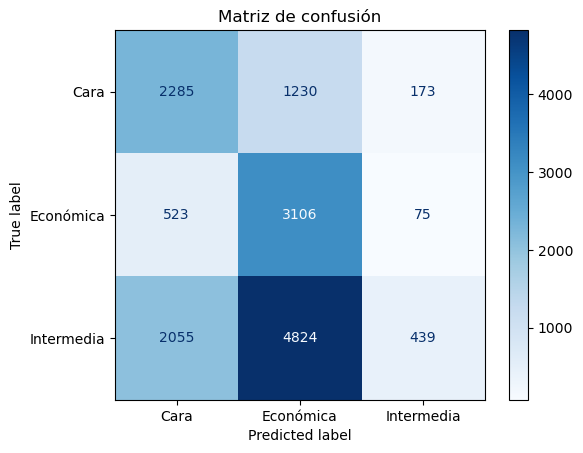

In [33]:
modeloNB=GaussianNB(var_smoothing=1e-20)
modeloNB.fit(X_train, y_train)
kfold = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
y_pred=cross_val_predict(modeloNB,X_test, y_test,cv=kfold)

class_names = [str(c) for c in modeloNB.classes_]
cm = confusion_matrix(y_test, y_pred, labels=modeloNB.classes_)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión")
plt.show()

Se observa de la matriz de confusión que este modelo tiene mayor número de errores en cada parte de la matriz que el del inciso anterior. De manera que aunque es un buen modelo, es más propoenso a fallar que el del inciso anterior. 

Inciso 9: Modelos de regresión y claisficación de Naive Bayes